<a href="https://colab.research.google.com/github/LisethTiria/Biosenales-2025-1/blob/main/Pr%C3%A1ctica5/Practica5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

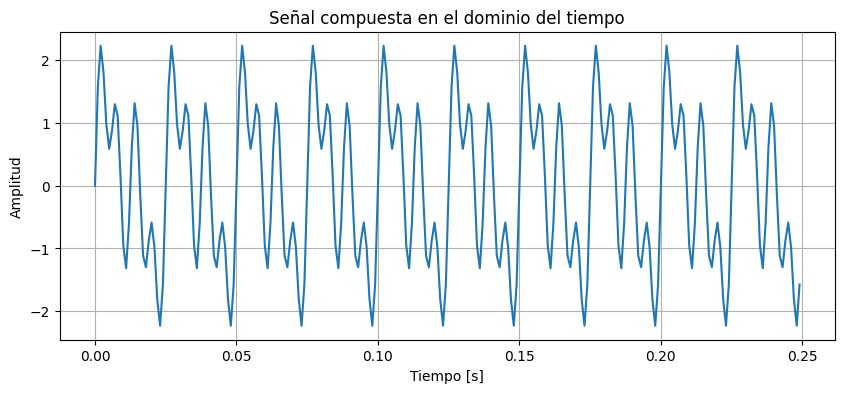

In [19]:
# ========================================
# 4.1 Señal compuesta y frecuencia de muestreo mínima
# ========================================
import numpy as np
import matplotlib.pyplot as plt

# Frecuencias de la señal
f1, f2, f3 = 40, 80, 160  # Hz

# Frecuencia de muestreo (mínima: 2*160=320 Hz, usamos más para mejor visualización)
fs = 1000  # Hz
t = np.arange(0, 10*(1/40), 1/fs)  # 10 periodos de la menor frecuencia (40 Hz)

# Señal compuesta
x = np.sin(2*np.pi*f1*t) + np.sin(2*np.pi*f2*t) + np.sin(2*np.pi*f3*t)

plt.figure(figsize=(10, 4))
plt.plot(t, x)
plt.title("Señal compuesta en el dominio del tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()


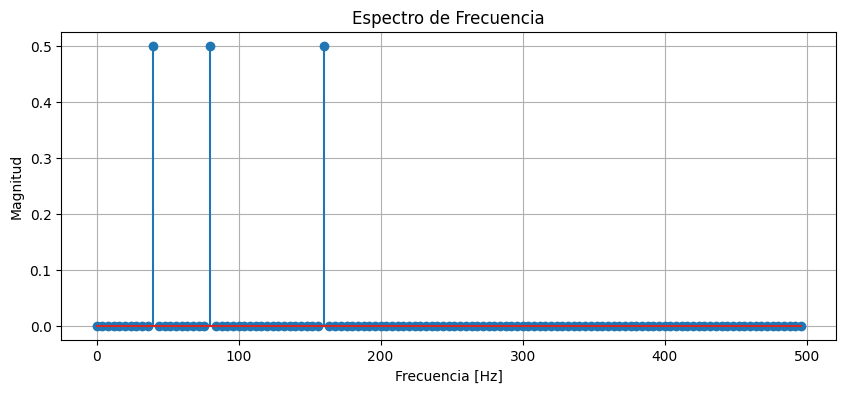

In [21]:
# ========================================
# 4.2 Transformada de Fourier y espectro
# ========================================
X = np.fft.fft(x)
N = len(X)
f = np.fft.fftfreq(N, d=1/fs)

plt.figure(figsize=(10, 4))
plt.stem(f[:N//2], np.abs(X[:N//2])/N)
plt.title("Espectro de Frecuencia")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid(True)
plt.show()

# Las frecuencias de 40, 80 y 160 Hz deberían ser claramente visibles


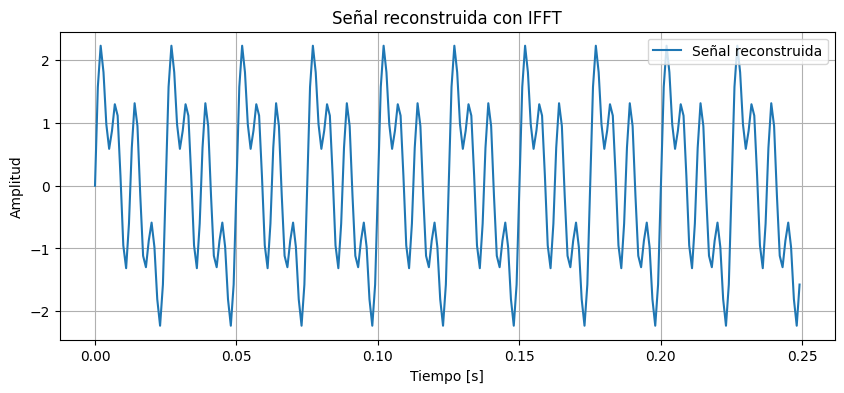

In [22]:
# ========================================
# 4.3 Transformada Inversa de Fourier
# ========================================
x_rec = np.fft.ifft(X)

plt.figure(figsize=(10, 4))
plt.plot(t, np.real(x_rec), label='Señal reconstruida')
plt.title("Señal reconstruida con IFFT")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()


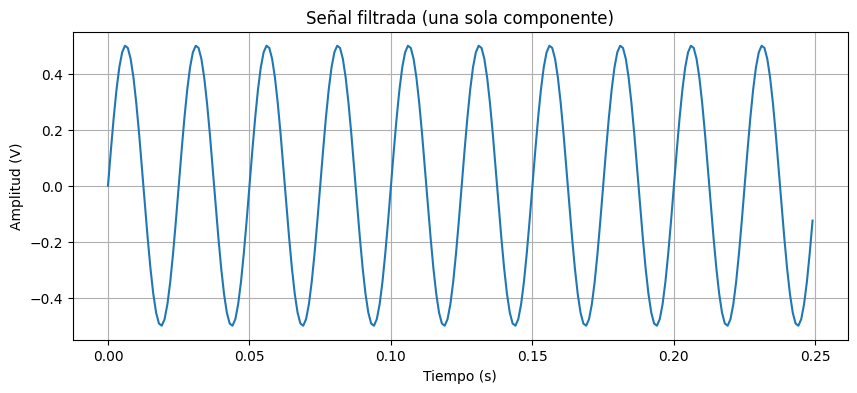

In [23]:
# ========================================
# 4.4 Aplicación de filtro por eliminación de frecuencias
# ========================================
F1 = np.fft.fft(x)
F2 = np.zeros(len(F1), dtype=complex)
F2[9:13] = F1[9:13]
xr = np.fft.ifft(F2)

plt.figure(figsize=(10, 4))
plt.plot(t, np.real(xr))
plt.title("Señal filtrada (una sola componente)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True)
plt.show()

# ¿Es un filtro? Sí. Se están eliminando todas las frecuencias excepto las cercanas a una en particular
# (por su posición en el vector FFT). Por tanto, se aplica una especie de filtro pasa banda o pasa bajas según el caso.


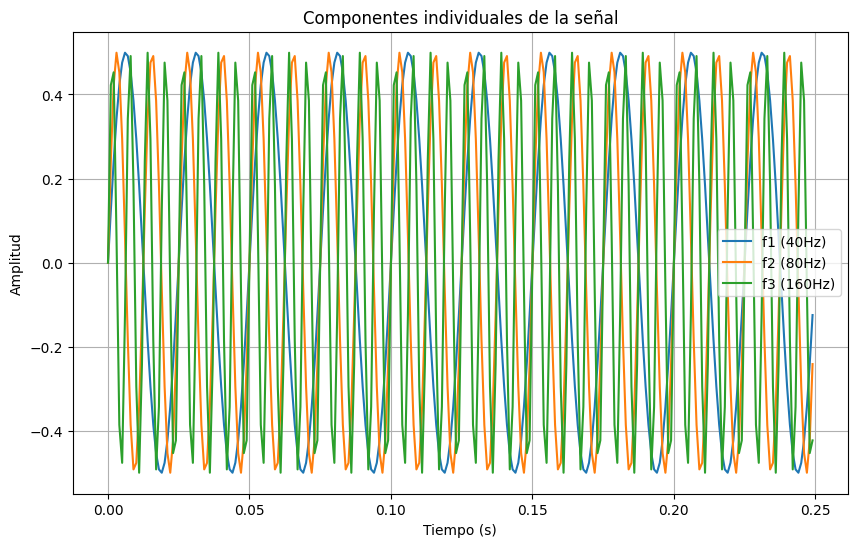

In [24]:
# ========================================
# Extra: extracción de cada componente individualmente
# ========================================
def extraer_componente(X, idx_range):
    F = np.zeros(len(X), dtype=complex)
    F[idx_range] = X[idx_range]
    return np.fft.ifft(F)

X_fft = np.fft.fft(x)
componentes = {
    "f1 (40Hz)": [9,10,11,12],  # Ajustar según el N y fs
    "f2 (80Hz)": [19,20,21,22],
    "f3 (160Hz)": [39,40,41,42],
}

plt.figure(figsize=(10, 6))
for i, (nombre, indices) in enumerate(componentes.items()):
    comp = extraer_componente(X_fft, indices)
    plt.plot(t, np.real(comp), label=nombre)

plt.title("Componentes individuales de la señal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.legend()
plt.show()


In [26]:
# ========================================
# 4.5 Análisis y filtrado de señal ECG (corregido)
# ========================================
from scipy.io import loadmat
from scipy.signal import welch
from scipy.signal.windows import hann

# Cargar archivo .mat
mat = loadmat("senecg.mat")
print(mat.keys())
ecg = mat['ecg'].squeeze()  # Ajustar el nombre si es diferente
fs_ecg = 250

# Periodograma de Welch
win = hann(256)
f_ecg, Pxx = welch(ecg, fs=fs_ecg, window=win, nperseg=256, noverlap=128)

plt.figure(figsize=(10, 4))
plt.semilogy(f_ecg, Pxx)
plt.title("Periodograma de Welch de la señal ECG")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia")
plt.grid(True)
plt.show()


error: Error -3 while decompressing data: unknown compression method

In [ ]:
# ========================================
# 4.6 Análisis de señales EEG Sano vs Parkinson
# ========================================
# Asumimos que tienes dos señales ya cargadas: eeg_sano y eeg_parkinson
# fs = frecuencia de muestreo

# Simulación (remplazar por carga real)
fs_eeg = 256
np.random.seed(0)
eeg_sano = np.sin(2*np.pi*10*np.arange(0, 10, 1/fs_eeg)) + 0.5*np.random.randn(int(10*fs_eeg))
eeg_parkinson = np.sin(2*np.pi*6*np.arange(0, 10, 1/fs_eeg)) + 0.5*np.random.randn(int(10*fs_eeg))

win = hann(512)
f_sano, Pxx_sano = welch(eeg_sano, fs=fs_eeg, window=win, nperseg=512, noverlap=256)
f_park, Pxx_park = welch(eeg_parkinson, fs=fs_eeg, window=win, nperseg=512, noverlap=256)

plt.figure(figsize=(10, 4))
plt.semilogy(f_sano, Pxx_sano, label='EEG Sano')
plt.semilogy(f_park, Pxx_park, label='EEG Parkinson')
plt.title("Comparación de periodogramas EEG")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad espectral de potencia")
plt.grid(True)
plt.legend()
plt.show()

# Justificación ventana y solapamiento:
# - Se usa ventana Hanning para reducir fugas espectrales.
# - nperseg = 512 permite buena resolución sin perder demasiada precisión temporal.
# - noverlap = 256 permite suavizar la media entre ventanas consecutivas.
